# FloodGuard — Resgate de animais em uma enchente com Aprendizado por Reforço

- **Disciplina:** Aprendizado por Reforço / Modelagem de MDPs — UNISINOS
- **Alunas**: Leticia Pillar Lisboa e Priscila Arruda
- **Algoritmos:** DQN, PPO e A2C (stable-baselines3) 
- **Ambiente:** Gymnasium, grid 6×6

Este notebook é o relatório do trabalho, escrito no estilo *literate programming*: cada bloco de código é
precedido por um texto que explica o que ele faz e seguido da discussão do que se observa. Todas as tabelas e
figuras são **lidas dos arquivos gerados pelos experimentos** (pasta `results/`), então o texto pode ser
conferido contra os dados.

## Sumário

1. [Introdução](#1.-Introdução)
2. [Modelagem do problema](#2.-Modelagem-do-problema)
   - 2.1 [Formalização do MDP](#2.1-Formalização-do-MDP) 
   - 2.2 [O ambiente `FloodGuardEnv`](#2.2-O-ambiente-FloodGuardEnv) 
   - 2.3 [Visualização](#2.3-Visualização)
3. [Metodologia de experimentos](#3.-Metodologia-de-experimentos)
   - 3.1 [Algoritmos](#3.1-Algoritmos) 
   - 3.2 [Métricas e baseline](#3.2-Métricas-e-baseline-aleatório)
   - 3.3 [Integração com o SB3](#3.3-Integração-com-o-stable-baselines3) 
   - 3.4 [Otimização de hiperparâmetros](#3.4-Otimização-de-hiperparâmetros-(Optuna)) 
   - 3.5 [Experimentos finais](#3.5-Protocolo-dos-experimentos-finais)
4. [Resultados](#4.-Resultados)
   - 4.1 [Baseline](#4.1-Baseline-aleatório) 
   - 4.2 [Busca de hiperparâmetros](#4.2-Busca-de-hiperparâmetros) 
   - 4.3 [Comparação final](#4.3-Comparação-final) 
   - 4.4 [Curvas de aprendizado](#4.4-Curvas-de-aprendizado) 
   - 4.5 [Comportamento aprendido](#4.5-Comportamento-aprendido-e-o-trade-off-proteção-×-resgate) 
   - 4.6 [Ablações](#4.6-Ablações-do-PPO) 
   - 4.7 [Reprodutibilidade](#4.7-Reprodutibilidade-da-busca)
5. [Conclusões](#5.-Conclusões)

In [1]:
# Configuração comum: caminhos, bibliotecas e duas funções de apoio para tabelas e figuras.
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

RES = ROOT / "results"
pd.set_option("display.max_columns", 40, "display.width", 200, "display.float_format", "{:.2f}".format)

_fig_counter = {"fig": 1, "tab": 0}  # a Figura 1 é a do episódio de exemplo (seção 2.3)


def figura(caminho, legenda, width=760):
    # Mostra uma figura salva em results/ e numera a legenda.
    _fig_counter["fig"] += 1
    display(Image(filename=str(RES / caminho), width=width))
    display(Markdown(f"*Figura {_fig_counter['fig']} — {legenda}*"))


def tabela(df, legenda):
    # Mostra um DataFrame com legenda numerada.
    _fig_counter["tab"] += 1
    display(Markdown(f"**Tabela {_fig_counter['tab']} — {legenda}**"))
    display(df)


ALGOS = ["dqn", "ppo", "a2c"]
NOMES = {"dqn": "DQN", "ppo": "PPO", "a2c": "A2C"}
print("Projeto em:", ROOT)

Projeto em: /home/leticia/dev/unisinos/aprendizado-por-reforco-modelagem-mdp


<a id="1.-Introdução"></a>
# 1. Introdução

## Contexto

Em 2024, as enchentes no Rio Grande do Sul deixaram milhares de pessoas e animais ilhados em Porto Alegre, e
eventos como o El Niño tendem a intensificar esse tipo de cheia. Em uma situação assim, as equipes de resgate
enfrentam decisões difíceis sob tempo e energia limitados: ir direto ao animal que precisa de ajuda ou gastar
recursos antes para conter o avanço da água?

## O problema modelado

Modelamos uma versão simplificada dessa situação como um **Processo de Decisão de Markov (MDP)**: um robô
autônomo, em um grid 6×6 de uma região fictícia, precisa resgatar **um único animal** ilhado e levá-lo a uma
**zona segura** antes que a água o alcance. O robô tem **bateria limitada** (que só recarrega na base), pode
**instalar até 2 barreiras** que bloqueiam o avanço da água, e a água **avança de forma estocástica** a partir de
um foco de enchente. O ambiente combina navegação em um mapa que se degrada, gestão de um recurso escasso e uma
decisão de priorização entre **proteger** (barreiras) e **resgatar** (ir direto ao animal).

## Visão geral dos experimentos e principais descobertas

Implementamos o MDP como ambiente Gymnasium (`FloodGuard-v0`) e comparamos três algoritmos de RL profundo do
stable-baselines3 — **DQN**, **PPO** e **A2C** —, primeiro com hiperparâmetros padrão, depois com
hiperparâmetros otimizados via **Optuna** (30 configurações por algoritmo), sempre com 5 seeds de treino de
500 mil passos e 100 episódios de teste por modelo.

Os principais resultados (detalhados na [seção 4](#4.-Resultados)):

- **Os três algoritmos resolvem a tarefa** (configuração otimizada): sucesso acima de 97 % em avaliação
  determinística, contra 0 % do agente aleatório (retorno em torno de −97).
- **Só o DQN otimizado aprende a usar as barreiras**, superando o retorno do "resgate direto" (5,0). PPO e A2C
  convergem para o resgate direto e ignoram as barreiras.
- **A otimização de hiperparâmetros ajudou DQN e PPO, mas não o A2C**, cujo melhor trial foi o próprio default.
- **Há variância grande entre seeds** em alguns casos (por exemplo, PPO default e A2C otimizado), o que torna
  a comparação entre algoritmos dependente de múltiplas seeds.
- **A busca do Optuna não é totalmente reprodutível** entre execuções em paralelo (seção 4.7).

<a id="2.-Modelagem-do-problema"></a>
# 2. Modelagem do problema

<a id="2.1-Formalização-do-MDP"></a>
## 2.1 Formalização do MDP

O MDP foi formalizado na proposta validada com o professor (`proposta-validacao-enchente-simplificada.md`) e
implementado sem alterações estruturais. Os valores numéricos que a proposta deixava em aberto (magnitudes de
recompensa, custos de bateria, probabilidades) foram fixados no ambiente e calibrados na Etapa 3.

**Estado $S$.** Posição do robô; bateria (0–100); mapa de inundação 6×6 (seca / rasa / profunda); mapa de
barreiras 6×6; kits de barreira restantes; status do animal (aguardando / com o robô / salvo / perdido) e sua
posição; passos restantes. A observação é **totalmente observável**.

**Ações $A$** (`Discrete(6)`): mover para cima, baixo, esquerda, direita; `instalar_barreira`;
`esperar/carregar`. Resgate e entrega são **automáticos** ao ocupar a célula do animal e a zona segura.

**Transição $P$.**
- Movimento é determinístico no grid. Custo de bateria: **1** em célula seca, **3** em célula com água rasa;
  água profunda é intransponível e a borda do grid bloqueia o movimento.
- `instalar_barreira` consome 1 kit e **15** de bateria e "protege" a célula atual. É ignorada (no-op) sem
  kit, sem bateria suficiente, em célula já protegida ou em água profunda.
- `esperar/carregar` recarrega **+20** de bateria, somente sobre a base.
- **Avanço estocástico da água:** a cada passo, cada célula seca adjacente a uma célula inundada vira água rasa
  com probabilidade $p = 0{,}05$, e cada célula rasa vira profunda com probabilidade $q = 0{,}10$. Células com
  barreira não sofrem transição.

**Recompensa $R$.**

| Evento | Recompensa |
|---|---:|
| Entregar o animal na zona segura | +20 |
| Instalar barreira "efetiva" (célula rasa, ou seca e adjacente à água) | +5 |
| Cada passo | −1 |
| Animal perdido (célula com água profunda antes do resgate) | −20 |
| Bateria zerada fora da base | −30 |

**Terminação.** Entrega (sucesso), animal perdido, bateria zerada fora da base (todos `terminated`) ou 100
passos (`truncated`). **Fator de desconto:** $\gamma = 0{,}99$ como ponto de partida; o valor faz parte do espaço
de busca do Optuna.

**Cenário fixo.** O robô parte da base em (5,5), o animal está em (0,5), a zona segura em (5,0) e o foco da
enchente em (0,0). O caminho mais curto (5 passos para cima, 5 para baixo, 5 para a esquerda) tem 15 passos e
rende $20 - 15 = 5$ de retorno. Instalar barreiras efetivas no caminho pode elevar isso a até 13 (dois
kits, +5 cada, −1 por passo extra) — este é o **trade-off proteção × resgate** do problema.

<a id="2.2-O-ambiente-FloodGuardEnv"></a>
## 2.2 O ambiente `FloodGuardEnv`

O código abaixo é o próprio arquivo do ambiente (`floodguard/envs/flood_guard_env.py`), exibido a partir do
código-fonte para que o relatório nunca fique dessincronizado da implementação. O ambiente está registrado no
Gymnasium como `FloodGuard-v0`.

In [2]:
import inspect

import gymnasium as gym

import floodguard  # registra o FloodGuard-v0
from floodguard.envs.flood_guard_env import FloodGuardEnv

# Trecho mais importante: a dinâmica do step() e o avanço estocástico da água.
print(inspect.getsource(FloodGuardEnv.step))
print(inspect.getsource(FloodGuardEnv._advance_flood))

    def step(self, action: int):
        if not self.action_space.contains(action):
            raise ValueError(f"Acao invalida: {action}")

        reward = self.step_penalty
        terminated = False

        if action in self._ACTION_DELTAS:
            reward += self._handle_move(action)
        elif action == self.INSTALL_BARRIER:
            reward += self._handle_install_barrier()
        elif action == self.WAIT_CHARGE:
            self._handle_wait_charge()

        self.battery = int(np.clip(self.battery, 0, self.max_battery))

        # Resgate automatico ao ocupar a celula do animal; entrega automatica
        # (com recompensa) ao ocupar a zona segura carregando o animal.
        robot_cell = tuple(self.robot_pos.tolist())
        if self.animal_status == self.AWAITING and robot_cell == self.animal_start:
            self.animal_status = self.WITH_ROBOT
            self._pickup_step = self._steps + 1
        if self.animal_status == self.WITH_ROBOT and robot_cell == self

O `step()` aplica a ação, resolve resgate/entrega, avança a água (sem propagação em cascata dentro de um mesmo
passo) e só então avalia perda do animal, bateria zerada e truncamento — separando `terminated` de `truncated`
como exige a API do Gymnasium. Abaixo, criamos o ambiente via `gym.make`, inspecionamos os espaços e rodamos o
verificador oficial `check_env`.

In [3]:
from gymnasium.utils.env_checker import check_env

env = gym.make("FloodGuard-v0", render_mode="rgb_array")
print("Espaço de ação     :", env.action_space)
print("Espaço de observação:")
for nome, espaco in env.observation_space.spaces.items():
    print(f"  {nome:14s} {espaco}")

check_env(env.unwrapped, skip_render_check=True)
print("\ncheck_env: OK (nenhum erro)")

Espaço de ação     : Discrete(6)
Espaço de observação:
  animal_pos     Box(0, 5, (2,), int32)
  animal_status  Discrete(4)
  barrier_kits   Box(0, 2, (1,), int32)
  barrier_map    Box(0, 1, (6, 6), int32)
  battery        Box(0, 100, (1,), int32)
  flood_map      Box(0, 2, (6, 6), int32)
  robot_pos      Box(0, 5, (2,), int32)
  steps_left     Box(0, 100, (1,), int32)

check_env: OK (nenhum erro)


A observação é um `Dict` com 8 campos. Para os algoritmos do SB3 ela é achatada e normalizada para `[0, 1]`
(seção 3.3). A suíte de testes (`pytest`, 44 testes) cobre reset determinístico, custos de bateria, bloqueio por
água profunda/borda, barreiras, resgate, perda do animal, bateria zerada, truncamento, renderização e os
utilitários de treino e busca.

<a id="2.3-Visualização"></a>
## 2.3 Visualização

A renderização (`floodguard/rendering/renderer.py`, matplotlib) reproduz o mockup da proposta: o **triângulo
azul** é o robô (com indicador de bateria), **A** é o animal, **S** a zona segura, **B** a base, a linha
marrom uma barreira, e as células azul-claro/azul-escuro são água rasa/profunda. A figura abaixo mostra o
estado inicial, gerado agora pelo próprio ambiente.

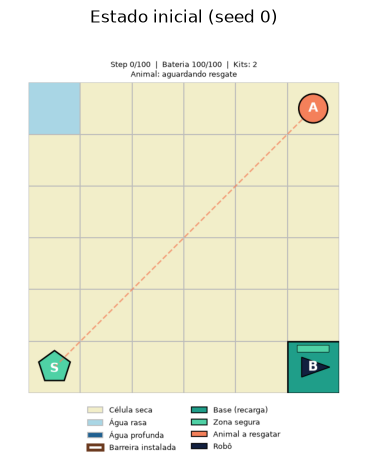

In [4]:
obs, info = env.reset(seed=0)
frame = env.render()
plt.figure(figsize=(4.5, 5.6)); plt.imshow(frame); plt.axis("off")
plt.title("Estado inicial (seed 0)"); plt.show()

Para ilustrar as mecânicas, o script `experiments/render_example_episode.py` executa uma **política heurística
fixa** (não é um agente treinado): o robô instala uma barreira, resgata o animal e o entrega enquanto a água
avança. Os quadros-chave e o GIF completo foram salvos em `results/figures/`.

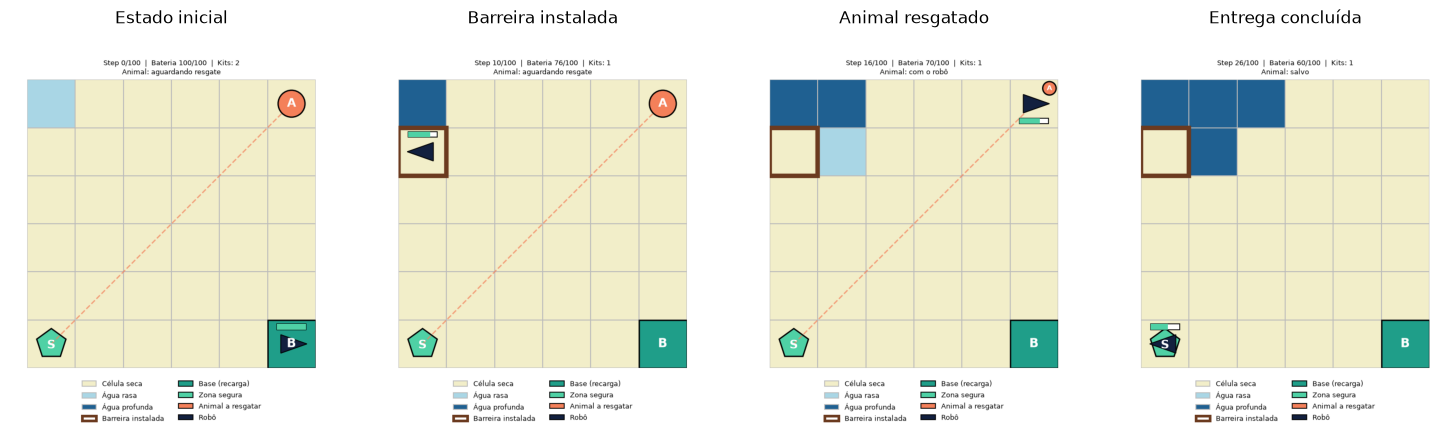

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4.4))
partes = [("example_episode_initial.png", "Estado inicial"), ("example_episode_barrier.png", "Barreira instalada"),
          ("example_episode_rescue.png", "Animal resgatado"), ("example_episode_final.png", "Entrega concluída")]
for ax, (arq, tit) in zip(axs, partes):
    ax.imshow(plt.imread(RES / "figures" / arq)); ax.set_title(tit); ax.axis("off")
plt.tight_layout(); plt.show()

*Figura 1 — Episódio de exemplo com política heurística. O GIF completo está em
`results/figures/example_episode.gif`.*

<a id="3.-Metodologia-de-experimentos"></a>
# 3. Metodologia de experimentos

<a id="3.1-Algoritmos"></a>
## 3.1 Algoritmos

O espaço de ação é discreto, então os três algoritmos são aplicáveis. Escolhemos um representante de cada
paradigma para contrastar estabilidade e eficiência amostral:

| Algoritmo | Paradigma | Por que foi escolhido |
|---|---|---|
| **DQN** | Baseado em valor, *off-policy* | Baseline clássico para ações discretas; usa *replay buffer*, reaproveitando experiência. |
| **PPO** | Gradiente de política, *on-policy* | Referência atual em RL profundo, conhecido por robustez. |
| **A2C** | *Actor-critic*, *on-policy* | Mais simples que o PPO; contraste em estabilidade e eficiência amostral. |

<a id="3.2-Métricas-e-baseline-aleatório"></a>
## 3.2 Métricas e baseline aleatório

Antes de gastar computação com RL profundo, a Etapa 3 executou um **agente aleatório** por 1000 episódios para
verificar se o ambiente está calibrado: nem trivial, nem impossível. A probabilidade de avanço da água foi
reduzida para $p = 0{,}05$ (mantendo $q = 0{,}10$) de modo que o agente aleatório tenha sucesso baixo, mas não
nulo, sem tornar a perda do animal irrelevante. As métricas abaixo foram fixadas e usadas em todos os
experimentos:

| Métrica | Significado |
|---|---|
| Retorno médio (`return_mean`) | Soma das recompensas originais do MDP por episódio. |
| Taxa de sucesso | Fração de episódios com animal entregue. |
| Taxa de perda do animal | Fração em que a água profunda alcançou o animal. |
| Taxa de truncamento | Fração que atingiu o limite de 100 passos. |
| Bateria zerada fora da base | Fração terminada por bateria esgotada. |
| Uso médio de bateria | Energia gasta em movimentos e barreiras. |
| Passos até o sucesso | Média nos episódios bem-sucedidos. |
| Barreiras instaladas / efetivas | Média por episódio; "efetiva" = em célula em risco imediato. |
| Travamento (`stalled_episode_rate`) | Fração de episódios com ≥ 10 passos consecutivos sem nenhum efeito no robô. |

<a id="3.3-Integração-com-o-stable-baselines3"></a>
## 3.3 Integração com o stable-baselines3

O script `experiments/train.py` monta o ambiente com os *wrappers* necessários e treina cada algoritmo com
`MlpPolicy` e hiperparâmetros padrão do SB3. Três decisões importantes:

1. **Observação achatada e normalizada.** O `Dict` é achatado (`FlattenObservation`) e reescalado para `[0, 1]`
   em `float32` (`NormalizeObservation`). Uma versão anterior usava o `RescaleObservation` do Gymnasium, que
   preserva o dtype inteiro e **truncava posição, bateria e passos para 0/1**, deixando o agente quase cego. O
   erro foi encontrado na Etapa 4, corrigido, coberto por teste de regressão, e **todos os resultados foram
   regerados** depois disso.
2. **Reward shaping só no treino.** O agente recebe um sinal denso de progresso (+5 ao se aproximar do próximo
   objetivo — animal ou zona segura —, −5 ao se afastar), sem conceder o progresso restante em finais
   malsucedidos. **A avaliação usa apenas a recompensa original do MDP.** Sem esse sinal, a recompensa do MDP é
   muito esparsa (a ablação da seção 4.6 confirma seu efeito).
3. **Avaliação determinística como principal.** Usa a ação de maior valor/probabilidade. É a política que o
   algoritmo aprendeu e a única comparável entre os três: no SB3, o modo "estocástico" do DQN é
   $\varepsilon$-greedy com o $\varepsilon$ final do treino, não uma política aprendida. A avaliação estocástica
   é reportada como análise secundária.

<a id="3.4-Otimização-de-hiperparâmetros-(Optuna)"></a>
## 3.4 Otimização de hiperparâmetros (Optuna)

O script `experiments/tune.py` executa, para cada algoritmo, um estudo Optuna com **30 trials**. Protocolo:

- **Mesmo orçamento por trial:** 100 mil passos, mesma seed de treino e mesmos episódios de avaliação (50 na
  avaliação final e 20 nas avaliações intermediárias). O banco de dados recusa trials de outro protocolo.
- **O trial 0 é o default do SB3**, para medir o ganho real da otimização.
- **Objetivo:** média dos retornos de avaliação **ao longo do treino** (área sob a curva de aprendizado). Como
  o cenário é fixo, várias configurações chegam ao retorno ótimo no final; a média ao longo do treino as
  desempata por velocidade de convergência. O retorno da avaliação final também é registrado.
- **Amostrador** `TPESampler` (com seed) e **poda** `MedianPruner`, que encerra cedo trials abaixo da mediana
  depois de um período de aquecimento, economizando computação.
- **Todos os trials** (inclusive os podados) ficam no SQLite (`results/logs/optuna/optuna_<algo>.db`) e em CSV.

Espaço de busca, definido em `suggest_hyperparams`:

In [6]:
espaco = pd.DataFrame([
    ("DQN", "learning_rate", "log-uniforme [1e-5, 3e-3]"),
    ("DQN", "buffer_size", "{10 mil, 25 mil, 50 mil, 100 mil}"),
    ("DQN", "batch_size", "{32, 64, 128, 256}"),
    ("DQN", "gamma", "uniforme [0,90; 0,9999]"),
    ("DQN", "exploration_fraction / exploration_final_eps", "uniforme [0,05; 0,50] / uniforme [0,01; 0,20]"),
    ("DQN", "target_update_interval", "{250, 500, 1000, 2000, 5000, 10000}"),
    ("DQN", "train_freq / gradient_steps / learning_starts", "{1, 4, 8, 16} / {1, 2, 4} / {100, 500, 1000, 2000}"),
    ("PPO", "learning_rate", "log-uniforme [1e-5, 3e-3]"),
    ("PPO", "n_steps", "{64, 128, 256, 512, 1024, 2048}"),
    ("PPO", "batch_size / n_epochs", "{32, 64, 128, 256} / {3, 5, 10, 20}"),
    ("PPO", "gamma / gae_lambda", "[0,90; 0,9999] / [0,80; 1,00]"),
    ("PPO", "clip_range / ent_coef / vf_coef", "[0,10; 0,40] / log [1e-8, 0,05] / [0,25; 1,00]"),
    ("A2C", "learning_rate", "log-uniforme [1e-5, 3e-3]"),
    ("A2C", "n_steps", "{5, 10, 20, 50, 100}"),
    ("A2C", "gamma / gae_lambda", "[0,90; 0,9999] / [0,80; 1,00]"),
    ("A2C", "ent_coef / vf_coef / max_grad_norm", "log [1e-8, 0,05] / [0,25; 1,00] / [0,30; 1,00]"),
], columns=["Algoritmo", "Hiperparâmetro", "Distribuição"])
tabela(espaco, "Espaço de busca do Optuna por algoritmo.")

**Tabela 1 — Espaço de busca do Optuna por algoritmo.**

,Algoritmo,Hiperparâmetro,Distribuição
0,DQN,learning_rate,"log-uniforme [1e-5, 3e-3]"
1,DQN,buffer_size,"{10 mil, 25 mil, 50 mil, 100 mil}"
2,DQN,batch_size,"{32, 64, 128, 256}"
3,DQN,gamma,"uniforme [0,90; 0,9999]"
4,DQN,exploration_fraction / exploration_final_eps,"uniforme [0,05; 0,50] / uniforme [0,01; 0,20]"
5,DQN,target_update_interval,"{250, 500, 1000, 2000, 5000, 10000}"
6,DQN,train_freq / gradient_steps / learning_starts,"{1, 4, 8, 16} / {1, 2, 4} / {100, 500, 1000, 2..."
7,PPO,learning_rate,"log-uniforme [1e-5, 3e-3]"
8,PPO,n_steps,"{64, 128, 256, 512, 1024, 2048}"
9,PPO,batch_size / n_epochs,"{32, 64, 128, 256} / {3, 5, 10, 20}"


<a id="3.5-Protocolo-dos-experimentos-finais"></a>
## 3.5 Protocolo dos experimentos finais

`experiments/final_experiments.py` treina, para cada algoritmo, a **melhor configuração do Optuna**
("otimizado") e a configuração **default do SB3**, com as mesmas **5 seeds** (42, 123, 2024, 7, 314), o mesmo
orçamento (**500 mil passos**) e os mesmos **100 episódios de teste** (seeds de teste a partir de 50000; as
avaliações periódicas durante o treino usam seeds disjuntas a partir de 90000). Reportamos **média ± desvio
padrão entre as seeds**. Também treinamos duas **ablações do PPO** — sem barreiras e sem *reward shaping* —
para investigar por que as barreiras quase não são usadas.

<a id="4.-Resultados"></a>
# 4. Resultados

<a id="4.1-Baseline-aleatório"></a>
## 4.1 Baseline aleatório

Resultado do agente aleatório em 1000 episódios (seed 42) — Etapa 3.

In [7]:
base = json.load(open(RES / "baselines" / "random_baseline_summary.json"))
linhas = {
    "Retorno médio": f"{base['return_mean']:.2f} ± {base['return_std']:.2f}",
    "Taxa de sucesso": f"{base['success_rate']:.1%}",
    "Taxa de perda do animal": f"{base['animal_lost_rate']:.1%}",
    "Taxa de truncamento": f"{base['truncated_rate']:.1%}",
    "Bateria zerada fora da base": f"{base['battery_depleted_rate']:.1%}",
    "Barreiras efetivas por episódio": f"{base['effective_barriers_installed_mean']:.2f}",
    "Uso médio de bateria": f"{base['battery_spent_mean']:.1f}",
}
tabela(pd.DataFrame({"Agente aleatório": linhas}), "Agente aleatório, 1000 episódios.")

**Tabela 2 — Agente aleatório, 1000 episódios.**

,Agente aleatório
Retorno médio,-95.95 ± 14.06
Taxa de sucesso,1.1%
Taxa de perda do animal,48.0%
Taxa de truncamento,49.8%
Bateria zerada fora da base,1.1%
Barreiras efetivas por episódio,0.05
Uso médio de bateria,73.3


O agente aleatório **quase nunca resolve** a tarefa (~1 %), perde o animal em cerca de metade dos episódios e
gasta quase todo o tempo sem concluir. Como o sucesso é baixo, mas não nulo, e a perda do animal é frequente, o
ambiente ficou **calibrado**: nem trivial, nem impossível. Também é notável que ele instala barreiras, mas quase
nunca em posições efetivas (0,05 por episódio).

<a id="4.2-Busca-de-hiperparâmetros"></a>
## 4.2 Busca de hiperparâmetros

Carregamos os CSV com **todos os trials** de cada algoritmo (30 por estudo).

In [8]:
trials = {a: pd.read_csv(RES / "logs" / "optuna" / f"{a}_trials.csv") for a in ALGOS}
resumo = []
for a, t in trials.items():
    comp = t[t.state == "COMPLETE"]
    melhor = comp.loc[comp.value.idxmax()]
    default = t.loc[t.number == 0].iloc[0]
    resumo.append({
        "Algoritmo": NOMES[a], "Trials": len(t), "Completos": len(comp), "Podados": int((t.state == "PRUNED").sum()),
        "Score do default": default.value, "Melhor score": melhor.value, "Melhor trial": int(melhor.number),
        "Retorno final (melhor)": melhor.user_final_return_mean, "Sucesso (melhor)": melhor.user_success_rate,
    })
tabela(pd.DataFrame(resumo).set_index("Algoritmo"),
       "Resumo da busca. *Score* = média do retorno de avaliação ao longo do treino de 100 mil passos.")

**Tabela 3 — Resumo da busca. *Score* = média do retorno de avaliação ao longo do treino de 100 mil passos.**

,Trials,Completos,Podados,Score do default,Melhor score,Melhor trial,Retorno final (melhor),Sucesso (melhor)
Algoritmo,,,,,,,,
DQN,30,20,10,-5.40,5.00,24,5.00,1.00
PPO,30,18,12,-8.31,2.88,25,5.00,1.00
A2C,30,15,15,4.14,4.14,0,4.18,1.00


Em DQN e PPO o melhor trial supera muito o default (score de −5,4 → 5,0 e −8,3 → 2,9). No **A2C, o melhor
trial é o próprio trial 0 (default)**: nenhuma das 29 configurações alternativas o superou. Note que o score
mistura velocidade de convergência e retorno final; vários trials chegam ao retorno final 5,0 (resgate direto)
e se diferenciam apenas pela velocidade.

As figuras abaixo mostram, por algoritmo, o histórico de otimização (valor de cada trial e o melhor até então)
e a importância dos hiperparâmetros.

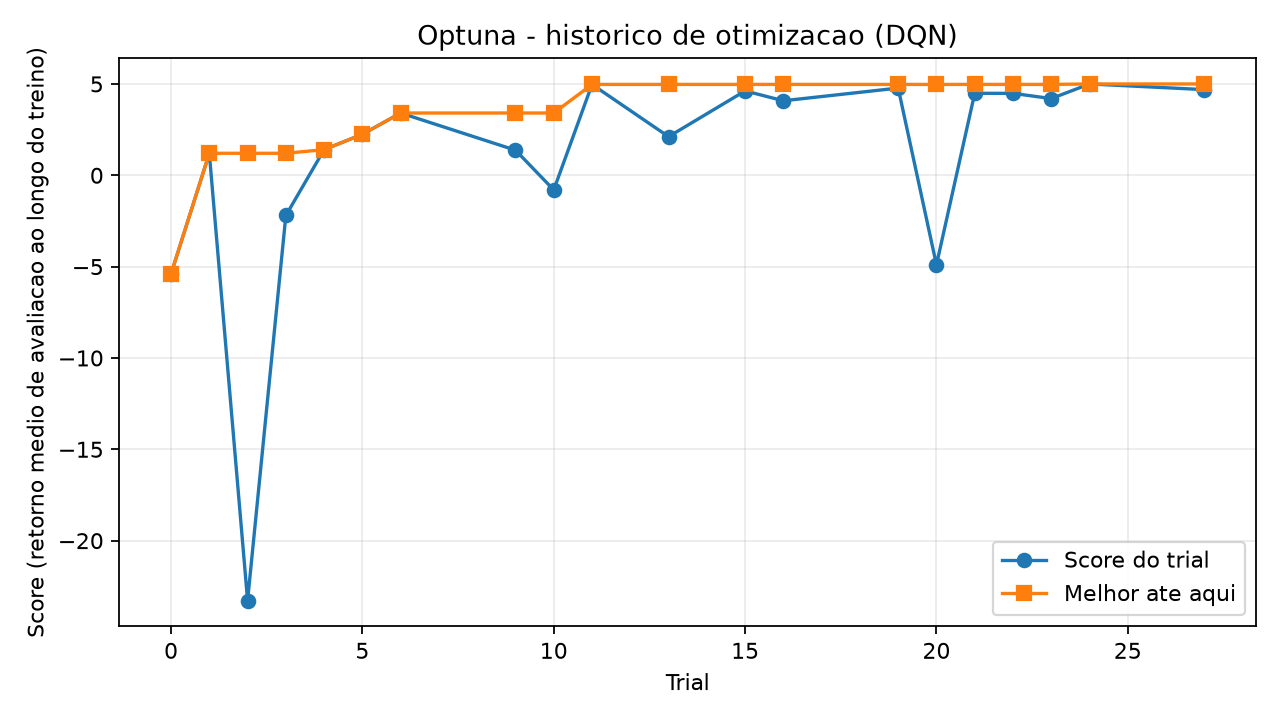

*Figura 2 — Histórico de otimização do Optuna — DQN.*

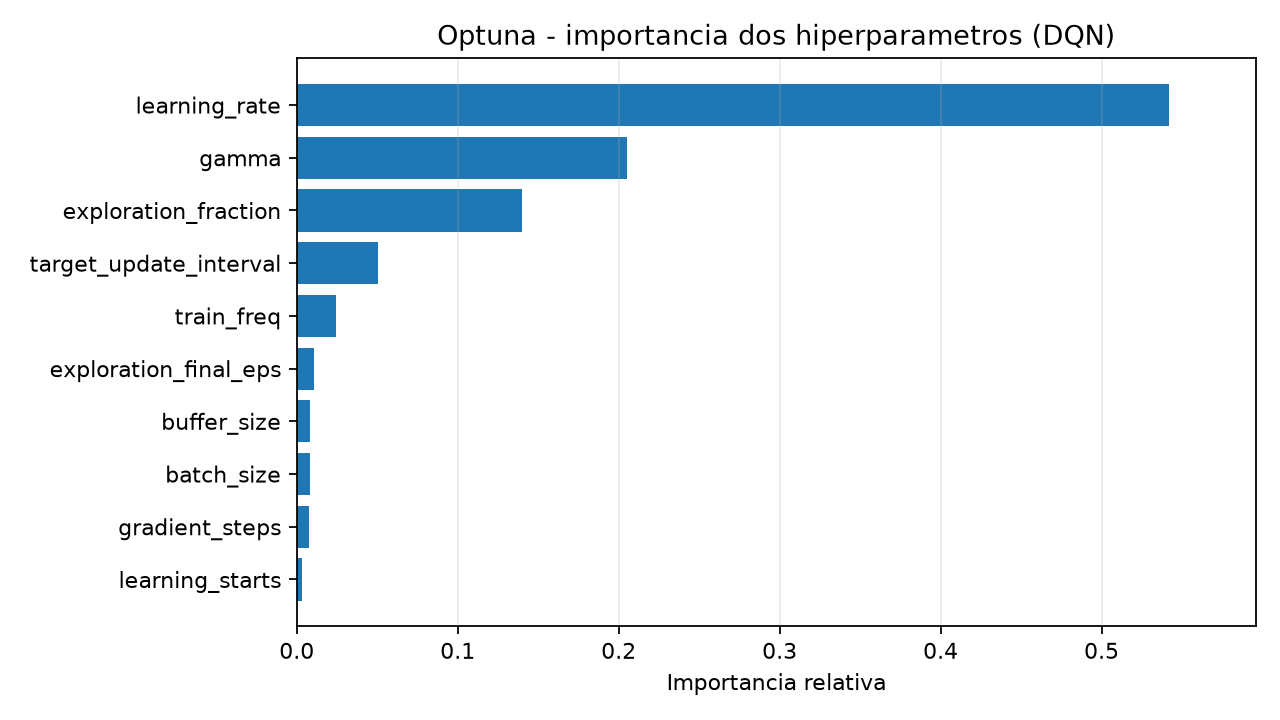

*Figura 3 — Importância dos hiperparâmetros — DQN.*

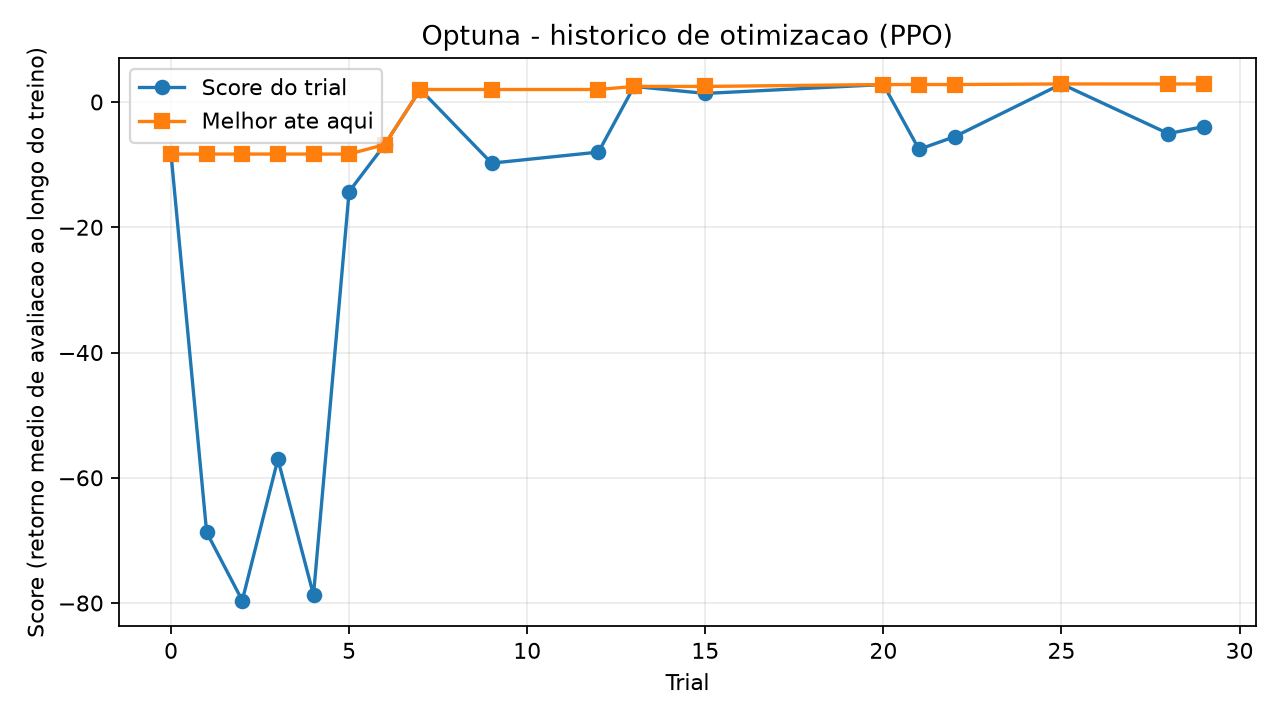

*Figura 4 — Histórico de otimização do Optuna — PPO.*

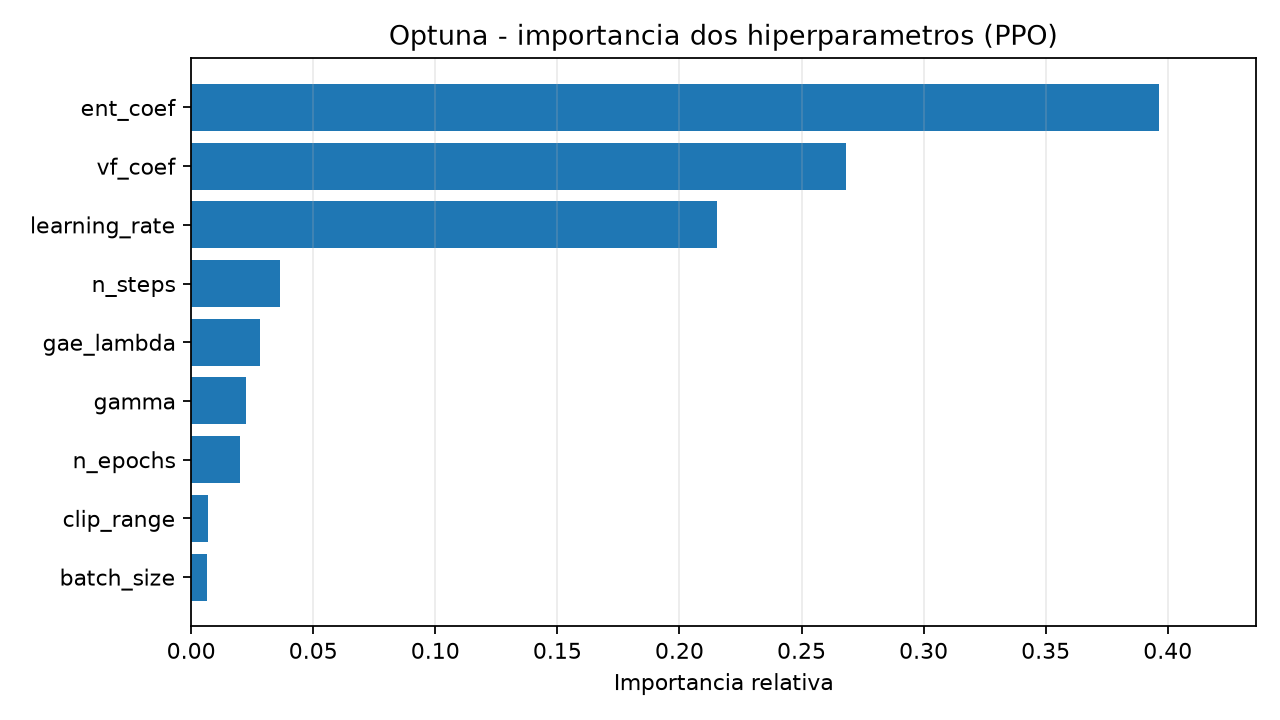

*Figura 5 — Importância dos hiperparâmetros — PPO.*

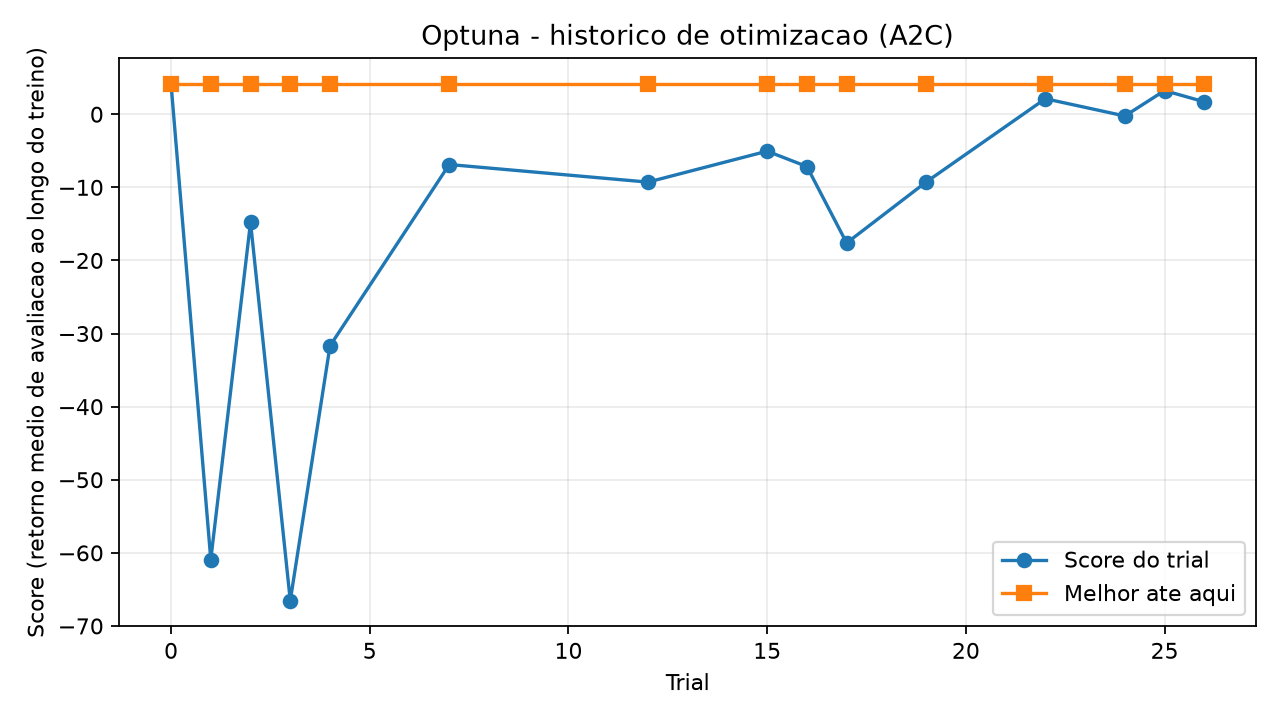

*Figura 6 — Histórico de otimização do Optuna — A2C.*

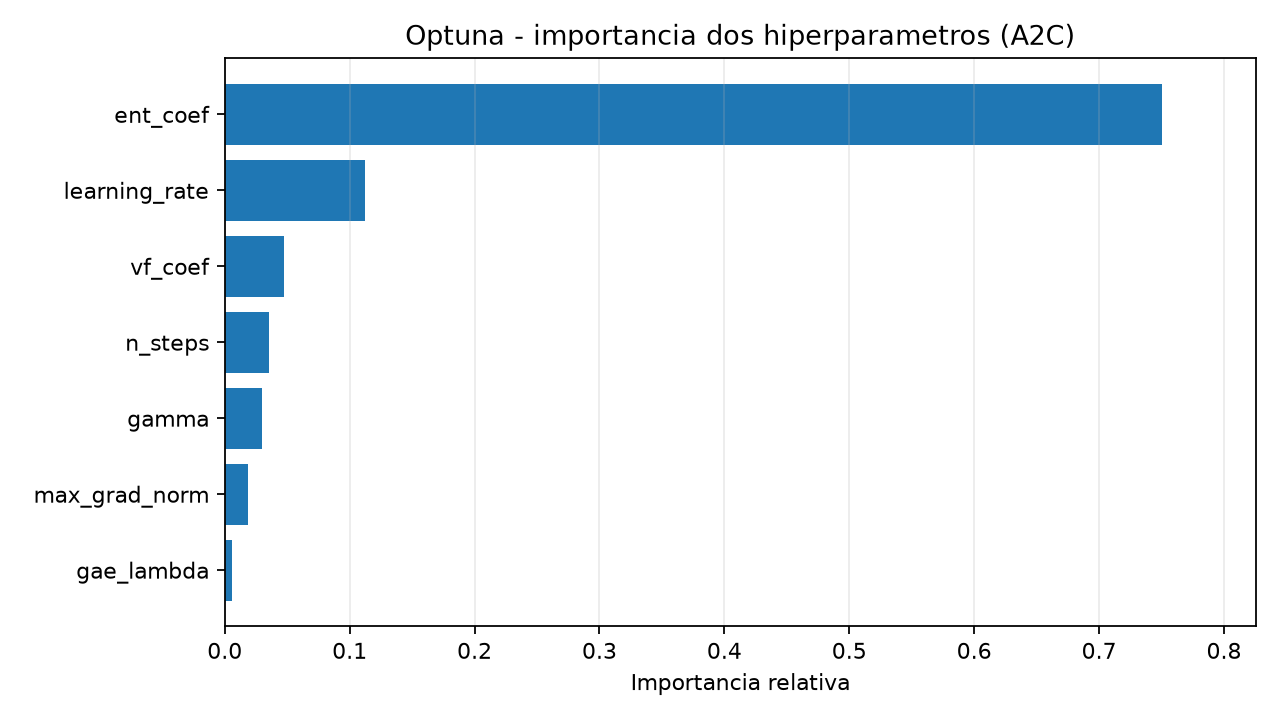

*Figura 7 — Importância dos hiperparâmetros — A2C.*

In [9]:
for a in ALGOS:
    figura(f"figures/optuna_{a}_history.png", f"Histórico de otimização do Optuna — {NOMES[a]}.", width=620)
    figura(f"figures/optuna_{a}_param_importance.png", f"Importância dos hiperparâmetros — {NOMES[a]}.", width=620)

A configuração final de cada algoritmo, usada nos experimentos da seção 4.3, e a lista completa das
configurações testadas (a tabela pedida como "outras configurações"):

In [10]:
final = json.load(open(RES / "final" / "final_summary.json"))
cfg = pd.DataFrame(final["configs"]).T
cfg.index = [NOMES[i] for i in cfg.index]
tabela(cfg.T, "Hiperparâmetros da configuração final (melhor trial) de cada algoritmo.")

**Tabela 4 — Hiperparâmetros da configuração final (melhor trial) de cada algoritmo.**

,A2C,DQN,PPO
ent_coef,0.00,NaN,0.00
gae_lambda,1.00,NaN,0.92
gamma,0.99,0.92,0.94
learning_rate,0.00,0.00,0.00
max_grad_norm,0.50,NaN,NaN
n_steps,5.00,NaN,512.00
vf_coef,0.50,NaN,0.43
batch_size,NaN,256.00,64.00
buffer_size,NaN,50000.00,NaN
exploration_final_eps,NaN,0.18,NaN


In [11]:
for a in ALGOS:
    t = trials[a]
    cols = ["number", "state", "value", "user_final_return_mean", "user_success_rate"] + [c for c in t.columns if c.startswith("params_")]
    df = t[cols].rename(columns=lambda c: c.replace("params_", "").replace("user_", ""))
    df = df.rename(columns={"number": "trial", "state": "estado", "value": "score"}).set_index("trial")
    tabela(df, f"Todas as configurações testadas — {NOMES[a]} (trial 0 = default do SB3).")

**Tabela 5 — Todas as configurações testadas — DQN (trial 0 = default do SB3).**

,estado,score,final_return_mean,success_rate,batch_size,buffer_size,exploration_final_eps,exploration_fraction,gamma,gradient_steps,learning_rate,learning_starts,target_update_interval,train_freq
trial,,,,,,,,,,,,,,
0,COMPLETE,-5.40,5.00,1.00,32,100000,0.05,0.10,0.99,1,0.00,100,10000,4
1,COMPLETE,1.21,4.60,1.00,128,10000,0.19,0.06,0.97,4,0.00,100,250,8
2,COMPLETE,-23.28,-21.78,0.78,32,100000,0.03,0.25,0.97,2,0.00,500,1000,16
3,COMPLETE,-2.20,4.60,1.00,128,100000,0.20,0.08,0.98,1,0.00,2000,2000,1
4,COMPLETE,1.41,5.00,1.00,128,10000,0.01,0.24,0.95,2,0.00,100,10000,8
5,COMPLETE,2.25,5.00,1.00,256,50000,0.11,0.48,0.92,2,0.00,1000,10000,8
6,COMPLETE,3.41,5.00,1.00,256,50000,0.11,0.50,0.91,2,0.00,1000,5000,8
7,PRUNED,-3.05,NaN,NaN,256,25000,0.13,0.49,0.91,4,0.00,1000,5000,4
8,PRUNED,-35.40,NaN,NaN,64,50000,0.10,0.36,0.94,2,0.00,1000,500,16


**Tabela 6 — Todas as configurações testadas — PPO (trial 0 = default do SB3).**

,estado,score,final_return_mean,success_rate,batch_size,clip_range,ent_coef,gae_lambda,gamma,learning_rate,n_epochs,n_steps,vf_coef
trial,,,,,,,,,,,,,
0,COMPLETE,-8.31,5.00,1.00,64,0.20,0.00,0.95,0.99,0.00,10,2048,0.50
1,COMPLETE,-68.70,-100.00,0.00,32,0.26,0.00,0.86,0.92,0.00,3,128,0.47
2,COMPLETE,-79.60,-18.84,0.82,256,0.13,0.00,0.86,0.98,0.00,20,2048,0.58
3,COMPLETE,-57.05,-43.60,0.62,256,0.16,0.00,0.82,0.99,0.00,5,512,0.49
4,COMPLETE,-78.71,-100.00,0.00,128,0.12,0.00,0.95,0.97,0.00,10,256,0.34
5,COMPLETE,-14.30,4.62,1.00,64,0.39,0.02,0.98,0.90,0.00,10,2048,0.96
6,COMPLETE,-6.79,3.98,1.00,64,0.28,0.00,0.93,0.94,0.00,10,64,0.83
7,COMPLETE,2.00,0.72,0.96,64,0.36,0.04,0.90,0.95,0.00,5,64,0.99
8,PRUNED,-100.00,NaN,NaN,32,0.40,0.04,0.90,0.95,0.00,5,1024,0.73


**Tabela 7 — Todas as configurações testadas — A2C (trial 0 = default do SB3).**

,estado,score,final_return_mean,success_rate,ent_coef,gae_lambda,gamma,learning_rate,max_grad_norm,n_steps,vf_coef
trial,,,,,,,,,,,
0,COMPLETE,4.14,4.18,1.00,0.00,1.00,0.99,0.00,0.50,5,0.50
1,COMPLETE,-60.91,4.18,1.00,0.00,0.97,0.91,0.00,0.31,5,0.78
2,COMPLETE,-14.79,-24.44,0.72,0.00,0.89,0.95,0.00,0.40,5,0.71
3,COMPLETE,-66.53,-97.06,0.04,0.00,0.81,0.96,0.00,0.35,20,0.38
4,COMPLETE,-31.68,-16.94,0.80,0.00,0.82,0.94,0.00,0.94,5,0.28
5,PRUNED,-100.00,NaN,NaN,0.00,0.99,1.00,0.00,0.73,50,0.54
6,PRUNED,-100.00,NaN,NaN,0.02,0.92,1.00,0.00,0.62,100,0.94
7,COMPLETE,-6.88,-2.28,0.98,0.00,0.91,0.90,0.00,0.95,10,0.54
8,PRUNED,-100.00,NaN,NaN,0.04,0.87,0.97,0.00,0.54,50,0.99


<a id="4.3-Comparação-final"></a>
## 4.3 Comparação final

Métricas por modelo em 100 episódios de teste, avaliação **determinística**; a tabela agrega as 5 seeds
(média ± desvio padrão **entre seeds**). No agente aleatório o desvio é entre episódios.

In [12]:
seed_res = pd.read_csv(RES / "final" / "final_seed_results.csv")
det = seed_res[seed_res.eval_mode == "deterministic"]
ROT = {"default": "Default SB3", "tuned": "Otimizado (Optuna)"}


def agrega(df):
    linhas = []
    for (v, a), g in df.groupby(["variant", "algo"]):
        linhas.append({
            "Algoritmo": NOMES[a], "Configuração": ROT.get(v, v),
            "Retorno": f"{g.return_mean.mean():.2f} ± {g.return_mean.std(ddof=1):.2f}",
            "Sucesso": f"{g.success_rate.mean():.1%} ± {g.success_rate.std(ddof=1):.1%}",
            "Perda do animal": f"{g.animal_lost_rate.mean():.1%}",
            "Truncamento": f"{g.truncated_rate.mean():.1%}",
            "Bateria usada": f"{g.battery_spent_mean.mean():.1f}",
            "Passos até sucesso": f"{g.steps_to_success_mean.mean():.1f}",
            "Barreiras efetivas": f"{g.effective_barriers_installed_mean.mean():.2f}",
            "Episódios travados": f"{g.stalled_episode_rate.mean():.1%}",
        })
    return pd.DataFrame(linhas)


principal = agrega(det[det.variant.isin(["default", "tuned"])])
principal["_o"] = principal.Algoritmo.map({"DQN": 0, "PPO": 1, "A2C": 2})
principal = principal.sort_values(["Configuração", "_o"], ascending=[False, True]).drop(columns="_o")
rand = final["random_baseline"]
principal.loc[len(principal)] = ["Aleatório", "—", f"{rand['return_mean']:.2f} ± {rand['return_std']:.2f}",
                                 f"{rand['success_rate']:.1%}", f"{rand['animal_lost_rate']:.1%}",
                                 f"{rand['truncated_rate']:.1%}", f"{rand['battery_spent_mean']:.1f}", "n/a",
                                 f"{rand['effective_barriers_installed_mean']:.2f}", "n/a"]
tabela(principal.set_index(["Algoritmo", "Configuração"]),
       "Comparação final, avaliação determinística (média ± desvio entre 5 seeds; aleatório: 100 episódios).")

**Tabela 8 — Comparação final, avaliação determinística (média ± desvio entre 5 seeds; aleatório: 100 episódios).**

,,Retorno,Sucesso,Perda do animal,Truncamento,Bateria usada,Passos até sucesso,Barreiras efetivas,Episódios travados
Algoritmo,Configuração,,,,,,,,
DQN,Otimizado (Optuna),8.96 ± 3.19,99.2% ± 0.4%,0.0%,0.8%,34.2,16.3,1.23,1.0%
PPO,Otimizado (Optuna),4.51 ± 0.56,99.6% ± 0.5%,0.0%,0.4%,15.1,15.1,0.00,0.6%
A2C,Otimizado (Optuna),-4.12 ± 19.22,97.4% ± 4.7%,0.0%,2.6%,15.0,22.2,0.00,19.6%
DQN,Default SB3,5.00 ± 0.00,100.0% ± 0.0%,0.0%,0.0%,15.0,15.0,0.00,0.0%
PPO,Default SB3,-15.86 ± 44.88,79.8% ± 44.6%,11.0%,9.2%,13.1,15.5,0.00,20.4%
A2C,Default SB3,4.79 ± 0.45,99.8% ± 0.4%,0.0%,0.2%,15.3,15.0,0.00,0.2%
Aleatório,—,-97.42 ± 12.80,0.0%,42.0%,55.0%,74.6,n/a,0.09,n/a


**Leitura.**

- **Todos superam com folga o agente aleatório** (retorno ≈ −97, 0 % de sucesso): com a configuração
  otimizada, os três alcançam sucesso acima de 97 % na média das seeds (o PPO *default* fica em ≈ 80 %, por causa
  de uma seed que nunca resolve a tarefa).
- **Ranking por retorno (otimizados): DQN > PPO > A2C.** O DQN otimizado tem o maior retorno médio (≈ 9), pois é
  o único que ultrapassa o "resgate direto" (5,0) usando barreiras. PPO otimizado fica em ≈ 4,5 — resgate
  direto, com desvio pequeno entre seeds — e o A2C otimizado tem retorno médio negativo por causa de **uma seed
  ruim** (seed 42: 89 % de sucesso com 96 % dos episódios travados), como mostra a tabela por seed abaixo.
- **Efeito da otimização.** Melhorou DQN (5,0 → ≈ 9) e principalmente PPO (o default tem uma seed catastrófica,
  seed 7, com 0 % de sucesso; o otimizado tem todas as seeds em resgate direto). Para o A2C **não houve ganho**:
  a configuração "otimizada" é o default com `ent_coef` = 1e-8 em vez de 0, e essa diferença mínima
  provavelmente altera as trajetórias de treino o bastante para trocar qual seed falha — evidência de que o A2C é **instável entre
  seeds** neste problema, e de que a variância de seed é maior que o efeito dos hiperparâmetros.
- **Travamento.** Alguns modelos, sob política determinística, ficam repetindo uma ação sem efeito (por exemplo,
  andar contra a borda) até estourar o limite de passos. Isso explica truncamentos que não são falta de
  habilidade em navegar, e sim um ponto fixo da política determinística; a política estocástica escapa disso
  (tabela abaixo).

In [13]:
por_seed = det[det.variant.isin(["default", "tuned"])].pivot_table(
    index=["algo", "variant"], columns="seed", values="return_mean")
por_seed.index = [f"{NOMES[a]} — {ROT[v]}" for a, v in por_seed.index]
tabela(por_seed, "Retorno médio nos 100 episódios de teste, por seed de treino (avaliação determinística).")

**Tabela 9 — Retorno médio nos 100 episódios de teste, por seed de treino (avaliação determinística).**

seed,7,42,123,314,2024
A2C — Default SB3,4.95,5.00,5.00,5.00,3.99
A2C — Otimizado (Optuna),4.99,-38.49,3.95,5.00,3.95
DQN — Default SB3,5.00,5.00,5.00,5.00,5.00
DQN — Otimizado (Optuna),9.49,12.39,8.28,3.95,10.71
PPO — Default SB3,-96.11,4.99,5.03,4.79,2.01
PPO — Otimizado (Optuna),4.74,5.00,3.86,3.95,4.99


Uma avaliação **estocástica** (PPO/A2C amostrando da distribuição de ações; DQN $\varepsilon$-greedy) serve
para medir a sensibilidade a ruído de política. As diferenças entre os modos não são comparáveis entre
algoritmos (item 3 da seção 3.3), então esta tabela é secundária.

In [14]:
sto = seed_res[seed_res.eval_mode == "stochastic"]
sto = sto[sto.variant.isin(["default", "tuned"])]
tabela(agrega(sto).set_index(["Algoritmo", "Configuração"]).drop(columns=["Bateria usada", "Passos até sucesso"]),
       "Avaliação estocástica (secundária), média ± desvio entre 5 seeds.")

**Tabela 10 — Avaliação estocástica (secundária), média ± desvio entre 5 seeds.**

,,Retorno,Sucesso,Perda do animal,Truncamento,Barreiras efetivas,Episódios travados
Algoritmo,Configuração,,,,,,
A2C,Default SB3,4.79 ± 0.45,99.8% ± 0.4%,0.0%,0.2%,0.00,0.2%
DQN,Default SB3,4.21 ± 0.13,100.0% ± 0.0%,0.0%,0.0%,0.00,0.0%
PPO,Default SB3,-15.56 ± 45.50,80.2% ± 44.3%,8.4%,11.4%,0.01,20.2%
A2C,Otimizado (Optuna),-3.90 ± 18.70,97.8% ± 3.8%,0.0%,2.2%,0.00,19.6%
DQN,Otimizado (Optuna),4.75 ± 1.83,99.8% ± 0.4%,0.0%,0.2%,0.91,0.8%
PPO,Otimizado (Optuna),4.90 ± 0.08,100.0% ± 0.0%,0.0%,0.0%,0.00,0.2%


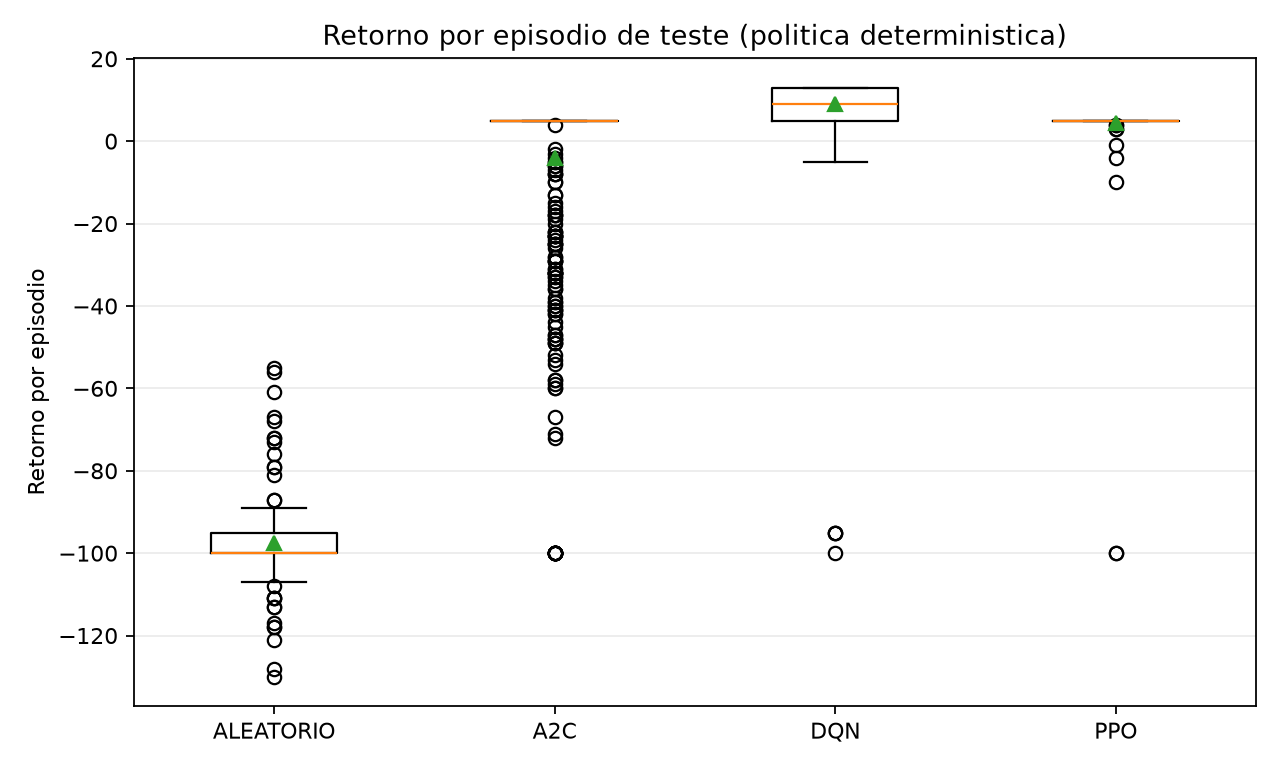

*Figura 8 — Distribuição do retorno nos episódios de teste, por algoritmo e configuração.*

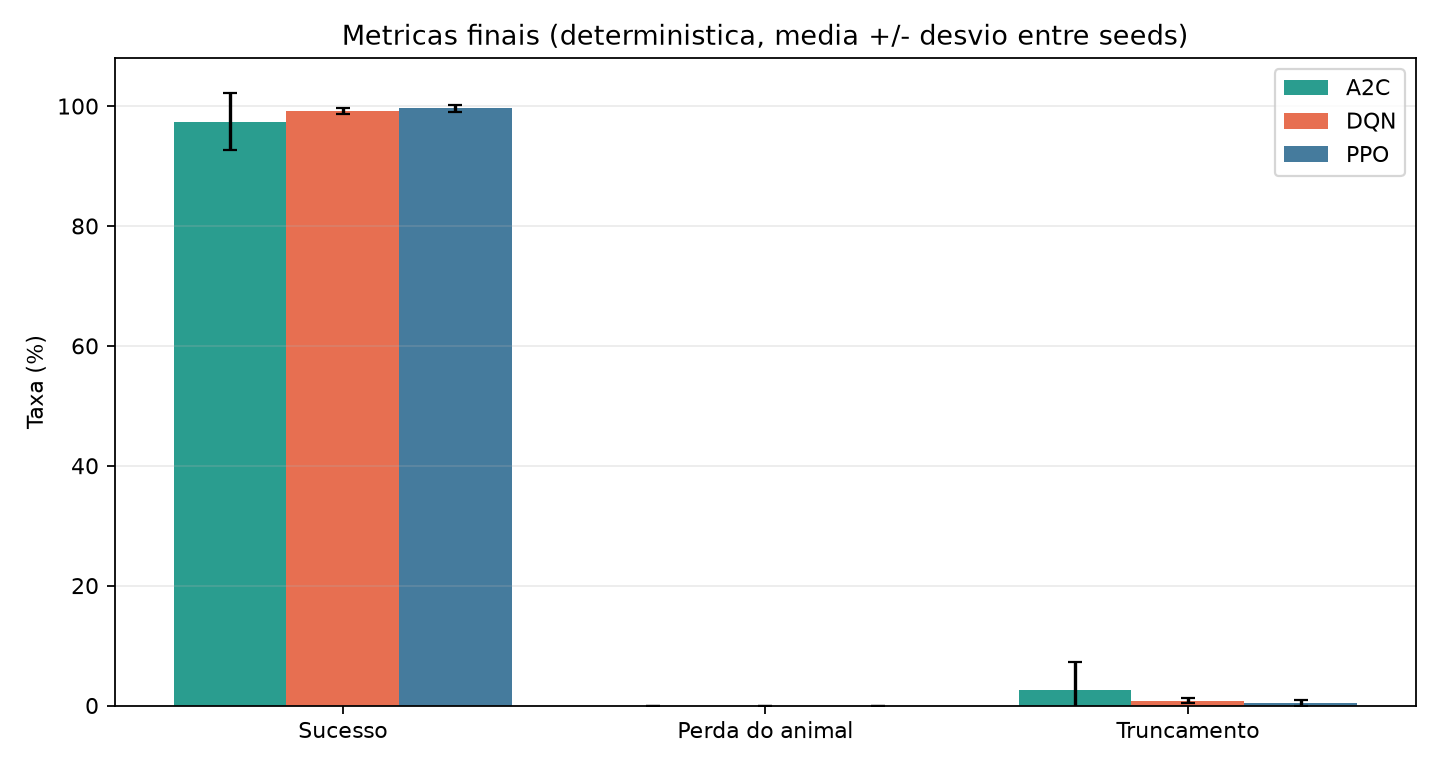

*Figura 9 — Métricas finais (avaliação determinística), média ± desvio entre seeds.*

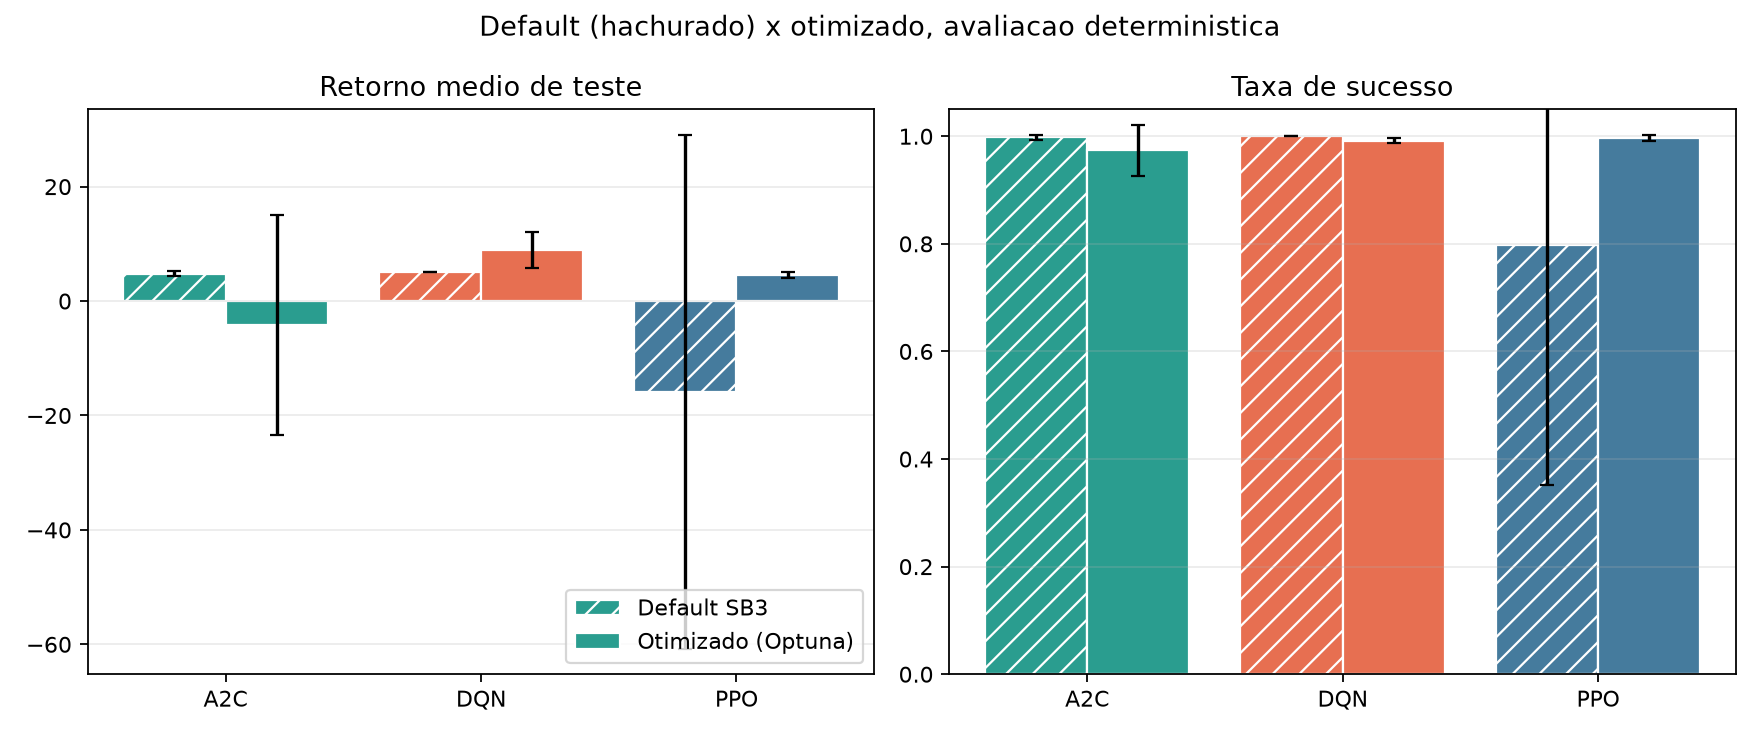

*Figura 10 — Default × otimizado, por algoritmo.*

In [15]:
figura("figures/stage6_return_boxplot.png", "Distribuição do retorno nos episódios de teste, por algoritmo e configuração.")
figura("figures/stage6_final_metrics.png", "Métricas finais (avaliação determinística), média ± desvio entre seeds.")
figura("figures/stage6_default_vs_tuned.png", "Default × otimizado, por algoritmo.")

<a id="4.4-Curvas-de-aprendizado"></a>
## 4.4 Curvas de aprendizado

As curvas de aprendizado mostram a recompensa de **treino** (que inclui o *reward shaping*, por isso está numa
escala maior que o retorno do MDP) ao longo dos 500 mil passos, média ± desvio entre seeds. A segunda figura
mostra a avaliação periódica durante o treino com a **recompensa original** e política determinística.

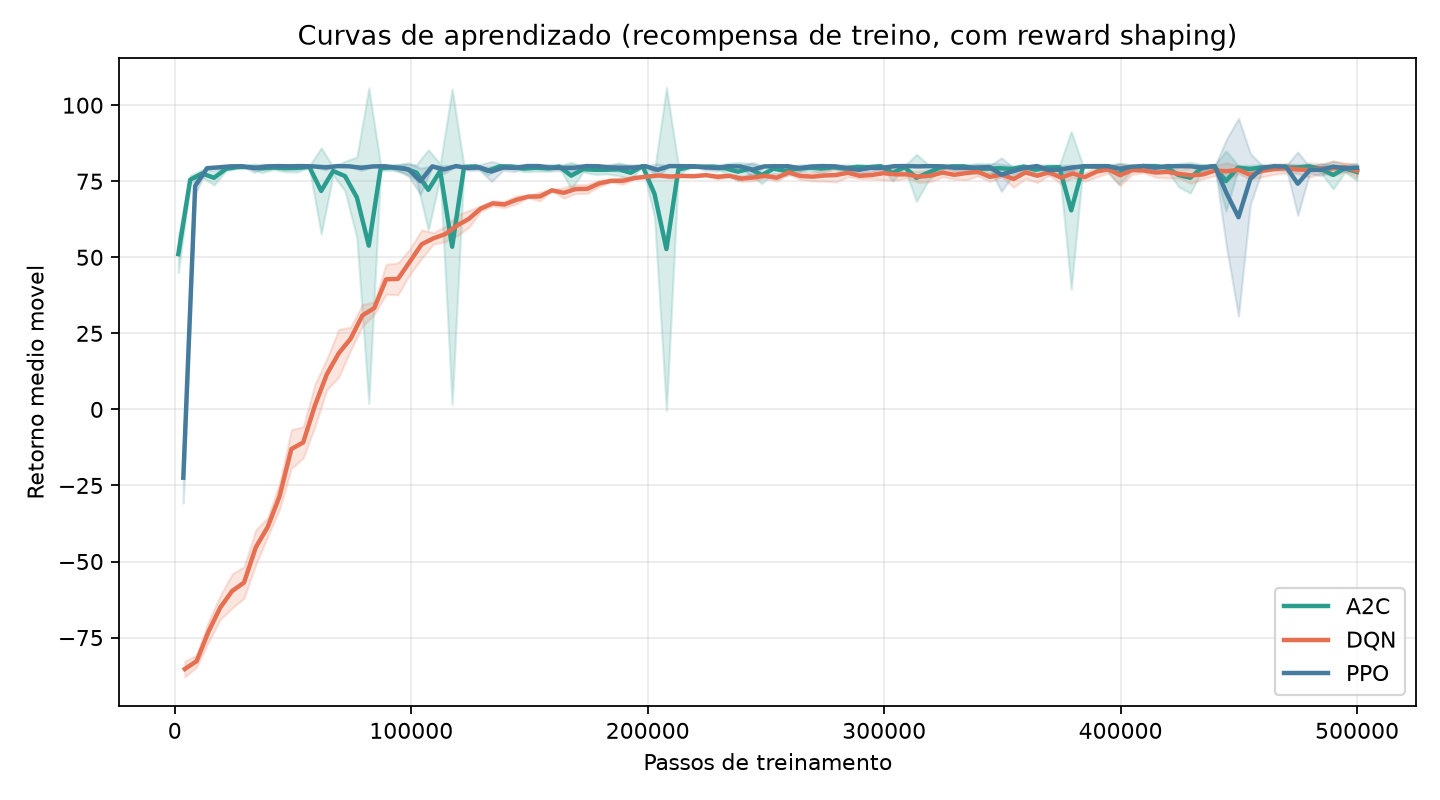

*Figura 11 — Recompensa de treino (com shaping) ao longo do treino, média entre seeds.*

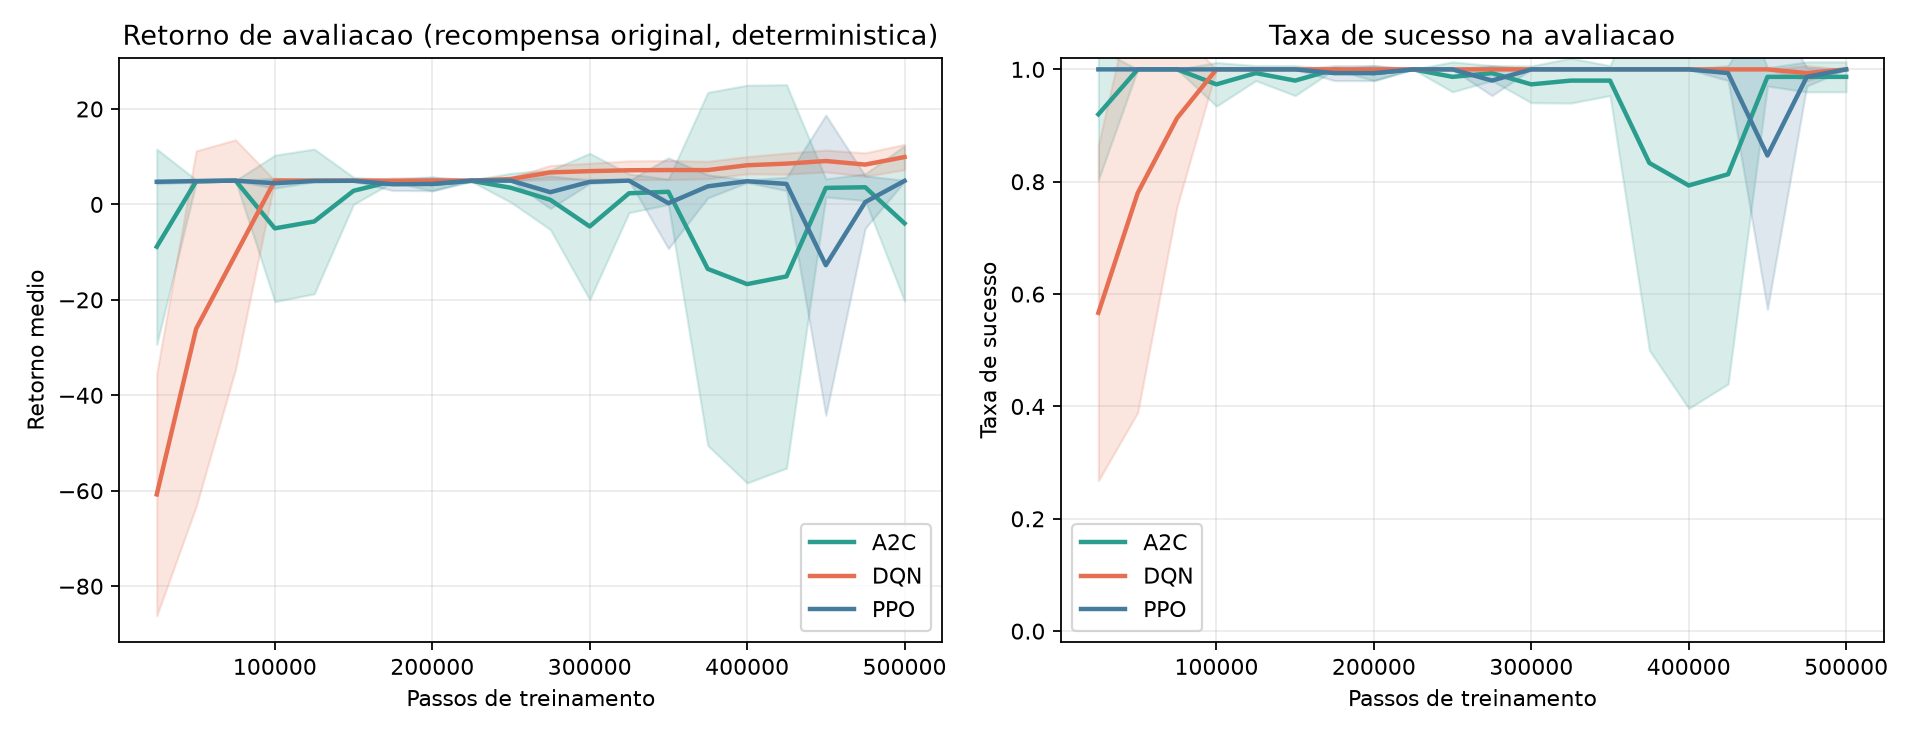

*Figura 12 — Avaliação periódica (recompensa original, determinística) ao longo do treino.*

In [16]:
figura("figures/stage6_learning_curves.png", "Recompensa de treino (com shaping) ao longo do treino, média entre seeds.")
figura("figures/stage6_eval_curves.png", "Avaliação periódica (recompensa original, determinística) ao longo do treino.")

In [17]:
# Passo do treino em que cada execução atingiu pela primeira vez retorno de avaliação >= 4.5
# (aproximadamente, o "resgate direto"), como medida de velocidade de convergência.
ev = pd.read_csv(RES / "final" / "eval_curves.csv")
ev = ev[ev.variant.isin(["default", "tuned"])]
def primeiro(g):
    h = g[g.return_mean >= 4.5].sort_values("step")
    return h.step.iloc[0] if len(h) else np.nan
conv = ev.groupby(["variant", "algo", "seed"]).apply(primeiro, include_groups=False).rename("passo").reset_index()
tab = conv.groupby(["algo", "variant"]).passo.agg(["median", "min", "max", lambda s: int(s.isna().sum())])
tab.columns = ["mediana", "mín", "máx", "seeds que não atingiram"]
tab.index = [f"{NOMES[a]} — {ROT[v]}" for a, v in tab.index]
tabela(tab, "Passo de treino em que a avaliação atinge pela primeira vez retorno ≥ 4,5 (5 seeds).")

**Tabela 11 — Passo de treino em que a avaliação atinge pela primeira vez retorno ≥ 4,5 (5 seeds).**

,mediana,mín,máx,seeds que não atingiram
A2C — Default SB3,25000.00,25000,50000,0
A2C — Otimizado (Optuna),25000.00,25000,50000,0
DQN — Default SB3,75000.00,50000,100000,0
DQN — Otimizado (Optuna),100000.00,75000,100000,0
PPO — Default SB3,50000.00,50000,50000,0
PPO — Otimizado (Optuna),25000.00,25000,50000,0


**Leitura.** PPO e A2C aprendem o resgate direto rápido (mediana de 25–50 mil passos), enquanto o DQN demora
mais (75–100 mil passos), coerente com um método *off-policy* que precisa preencher o *replay buffer* e explorar
com $\varepsilon$ decrescente. O contraste esperado entre "DQN lento, PPO estável, A2C rápido porém instável"
aparece parcialmente: o A2C converge cedo, mas é o que mais oscila entre seeds; o PPO otimizado é o mais
estável; e o DQN é o mais lento — porém é o único que, com mais tempo, descobre a estratégia de barreiras.

<a id="4.5-Comportamento-aprendido-e-o-trade-off-proteção-×-resgate"></a>
## 4.5 Comportamento aprendido e o trade-off proteção × resgate

O retorno de referência do MDP ajuda a interpretar o comportamento: o resgate direto rende 5,0 e, com duas
barreiras efetivas no caminho, até 13,0. Um retorno acima de 5 indica **uso de barreiras**.

In [18]:
ref = final["reference_returns"]
print(f"Referência: resgate direto = {ref['direct_rescue']}, com {ref['barrier_kits']} barreiras efetivas = {ref['with_effective_barriers']}")
uso = det[det.variant == "tuned"].groupby("algo")[["return_mean", "effective_barriers_installed_mean", "barriers_installed_mean"]].mean()
uso.index = [NOMES[a] for a in uso.index]
uso.columns = ["Retorno", "Barreiras efetivas / episódio", "Barreiras instaladas / episódio"]
uso.loc["Aleatório"] = [rand["return_mean"], rand["effective_barriers_installed_mean"], rand["barriers_installed_mean"]]
tabela(uso.loc[["DQN", "PPO", "A2C", "Aleatório"]], "Uso de barreiras pelos modelos otimizados (avaliação determinística).")

Referência: resgate direto = 5.0, com 2 barreiras efetivas = 13.0


**Tabela 12 — Uso de barreiras pelos modelos otimizados (avaliação determinística).**

,Retorno,Barreiras efetivas / episódio,Barreiras instaladas / episódio
DQN,8.96,1.23,1.23
PPO,4.51,0.00,0.00
A2C,-4.12,0.00,0.00
Aleatório,-97.42,0.09,2.00


O **DQN otimizado** instala em média cerca de 1,2 barreira efetiva por episódio (até 1,9 em algumas seeds) e por
isso obtém retornos de 8 a 12; quatro das cinco seeds usam barreiras, e a seed 314
fica no resgate direto (3,95). **PPO e A2C praticamente não usam barreiras.** Uma explicação plausível é que o
*reward shaping* de progresso e a avaliação com política determinística tornam o resgate direto um ótimo local
muito atrativo: instalar uma barreira exige parar (−1 por passo, sem progresso no shaping) e gastar 15 de
bateria, com ganho de +5 apenas se ela estiver em uma célula em risco. O DQN, com *replay buffer* e exploração
$\varepsilon$-greedy mais alta (0,18 de $\varepsilon$ final na configuração otimizada), encontra esses casos
raros e os consolida.

Para ilustrar, os GIFs de um episódio de teste determinístico por algoritmo (modelo otimizado, primeira seed)
foram salvos em `results/figures/stage6_episode_<algo>.gif`. Abaixo, o quadro final de cada um poderia ser
inspecionado; para o relatório, exibimos os GIFs diretamente:

DQN,PPO,A2C

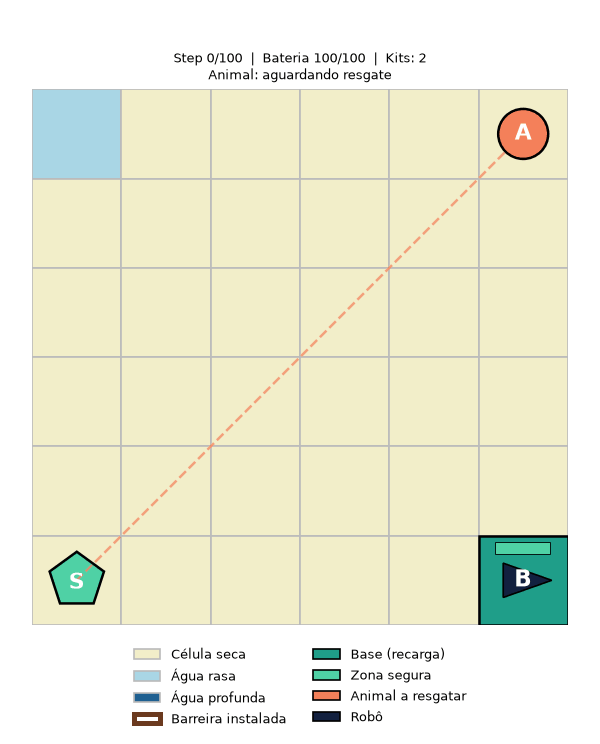
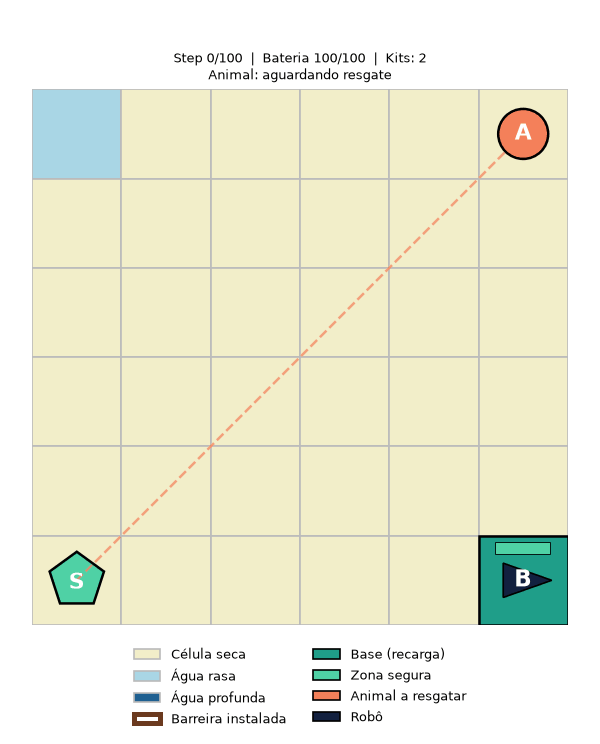
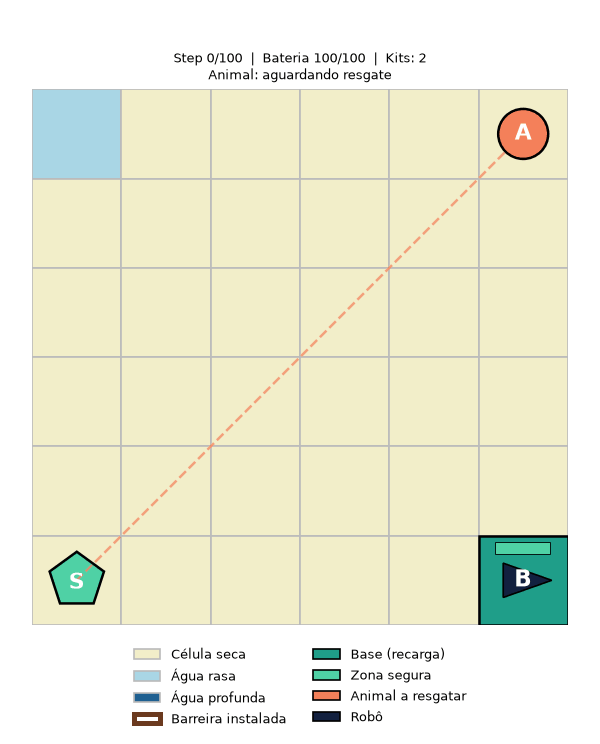

*Figura 13 — Episódio de teste determinístico com o modelo otimizado de cada algoritmo (mesmo cenário inicial).*

In [19]:
from IPython.display import HTML
import base64

def gif_inline(arq, largura=260):
    dados = base64.b64encode((RES / "figures" / arq).read_bytes()).decode()
    return f'<td style="text-align:center"><img src="data:image/gif;base64,{dados}" width="{largura}"><br><small>{arq.split("_")[-1][:-4].upper()}</small></td>'

display(HTML("<table><tr>" + "".join(gif_inline(f"stage6_episode_{a}.gif") for a in ALGOS) + "</tr></table>"))
_fig_counter["fig"] += 1
display(Markdown(f"*Figura {_fig_counter['fig']} — Episódio de teste determinístico com o modelo otimizado de cada algoritmo (mesmo cenário inicial).*"))

<a id="4.6-Ablações-do-PPO"></a>
## 4.6 Ablações do PPO

Para investigar por que o PPO ignora as barreiras, treinamos o PPO otimizado (5 seeds) em duas variantes:
**sem barreiras** (0 kits) e **sem reward shaping** (só a recompensa esparsa original).

In [20]:
abl = det[det.variant.isin(["tuned", "ppo_no_barriers", "ppo_no_shaping"]) & (det.algo == "ppo")]
NOM_ABL = {"tuned": "PPO otimizado (referência)", "ppo_no_barriers": "PPO otimizado sem barreiras", "ppo_no_shaping": "PPO otimizado sem reward shaping"}
linhas = []
for v, g in abl.groupby("variant"):
    linhas.append({"Variante": NOM_ABL[v], "Retorno": f"{g.return_mean.mean():.2f} ± {g.return_mean.std(ddof=1):.2f}",
                   "Sucesso": f"{g.success_rate.mean():.1%}", "Perda do animal": f"{g.animal_lost_rate.mean():.1%}",
                   "Truncamento": f"{g.truncated_rate.mean():.1%}", "Barreiras efetivas": f"{g.effective_barriers_installed_mean.mean():.2f}",
                   "Seeds com retorno > 5": int((g.return_mean > 5.5).sum())})
ordem = [NOM_ABL[k] for k in ["tuned", "ppo_no_barriers", "ppo_no_shaping"]]
tabela(pd.DataFrame(linhas).set_index("Variante").loc[ordem], "Ablações do PPO (avaliação determinística, 5 seeds).")
tabela(abl.pivot_table(index="variant", columns="seed", values="return_mean").rename(index=NOM_ABL).loc[ordem],
       "Retorno por seed nas ablações do PPO.")

**Tabela 13 — Ablações do PPO (avaliação determinística, 5 seeds).**

,Retorno,Sucesso,Perda do animal,Truncamento,Barreiras efetivas,Seeds com retorno > 5
Variante,,,,,,
PPO otimizado (referência),4.51 ± 0.56,99.6%,0.0%,0.4%,0.00,0
PPO otimizado sem barreiras,4.71 ± 0.51,99.8%,0.0%,0.2%,0.00,0
PPO otimizado sem reward shaping,-12.70 ± 41.72,79.6%,7.2%,13.2%,0.77,1


**Tabela 14 — Retorno por seed nas ablações do PPO.**

seed,7,42,123,314,2024
variant,,,,,
PPO otimizado (referência),4.74,5.00,3.86,3.95,4.99
PPO otimizado sem barreiras,4.91,5.00,5.00,3.80,4.83
PPO otimizado sem reward shaping,-87.23,5.00,9.83,4.88,4.00


**Leitura.**

- **Sem barreiras**, o PPO mantém o desempenho (retorno ≈ 4,7, sucesso ≈ 100 %): o resgate direto não depende
  de barreiras, e o PPO otimizado já as ignorava. As barreiras só *agregam* valor, não são necessárias.
- **Sem reward shaping**, o desempenho **cai e a variância explode**: uma seed nunca resolve a tarefa (0 % de
  sucesso), o retorno médio fica muito negativo, mas **duas seeds instalam barreiras** (1,9 efetivas por
  episódio) e uma delas atinge retorno ≈ 9,8. Sem o sinal de progresso, a exploração é mais aleatória, e o
  agente às vezes tropeça em barreiras efetivas. Isso mostra que o *reward shaping* torna o aprendizado do
  resgate confiável, ao custo de **empurrar o agente para o resgate direto** e reduzir a descoberta de
  barreiras. É o principal trade-off de projeto observado.

<a id="4.7-Reprodutibilidade-da-busca"></a>
## 4.7 Reprodutibilidade da busca

O pipeline foi **reexecutado do início ao fim** para gerar os resultados deste relatório. Comparamos com a
execução anterior (guardada no histórico do repositório):

| Etapa | Reproduziu exatamente? |
|---|---|
| Baseline aleatório (Etapa 3) | **Sim** |
| Treino default, seed 42 (Etapa 4) | **Sim** |
| Modelos "default" da Etapa 6 (5 seeds) | **Sim** |
| Busca do Optuna (Etapa 5) e modelos "otimizados" | **Não** |

Treinos e avaliações são determinísticos dada a seed. A busca da execução anterior compartilhava um mesmo
banco entre vários processos em paralelo (a ordem em que os trials terminam muda o que o TPE sugere a seguir);
nesta reexecução, com um processo por algoritmo, obtivemos outras configurações "ótimas" e, com elas, números
um pouco diferentes (DQN otimizado: retorno de 11,8 para 9,0; PPO otimizado: de 1,4 para 4,5). O **ranking dos
algoritmos e as conclusões qualitativas se mantiveram** (DQN é o único que usa barreiras; A2C otimizado não
melhora o default), mas isso mostra que **os números absolutos da etapa 5 e das colunas "otimizado" dependem da
execução da busca**, e que 30 trials com uma seed de treino por trial dão uma estimativa ruidosa.

<a id="5.-Conclusões"></a>
# 5. Conclusões

## Visão geral

Modelamos como MDP o resgate de um animal em uma enchente e implementamos o ambiente `FloodGuard-v0` em
Gymnasium, com renderização e testes automatizados. Um agente aleatório quase nunca tem sucesso (~1 %), o que
confirma que o ambiente não é trivial. DQN, PPO e A2C, com observação normalizada e *reward shaping* de
progresso, **aprendem a tarefa** (sucesso ≥ 97 % na configuração otimizada). Em retorno, **DQN otimizado > PPO otimizado > A2C
otimizado**, mas a diferença vem em grande parte de **quem descobre as barreiras**: só o DQN otimizado supera
o resgate direto (retorno ≈ 9 contra 5). A otimização do Optuna trouxe ganho para DQN e PPO, e nenhum para o
A2C. Também vimos que o *reward shaping* torna o treino confiável, mas reduz o uso de barreiras.

## Dificuldades encontradas

- **Calibração do MDP.** Os valores de $p$, $q$, custos e recompensas precisaram ser ajustados na Etapa 3 para
  que o agente aleatório tivesse sucesso baixo, mas não nulo.
- **Um erro sutil de observação.** O `RescaleObservation` truncava a observação inteira para 0/1 e fazia os
  agentes treinarem cegos; foi identificado na Etapa 4, corrigido, e todos os resultados foram regerados. Vale registrar como lição: **conferir o dtype e a escala** do que a rede recebe.
- **Recompensa esparsa.** Foi necessário *reward shaping* para o treino ser confiável.
- **Custo computacional da busca.** 90 trials de 100 mil passos mais 40 modelos finais de 500 mil passos
  levaram cerca de duas horas de máquina em paralelo (com 12 núcleos) na reexecução — a busca de hiperparâmetros
  foi a parte mais cara em relação ao ganho.
- **Variância entre seeds e reprodutibilidade da busca** (seções 4.3 e 4.7): conclusões a partir de uma única
  seed seriam enganosas — por exemplo, o A2C otimizado só parece pior que o default por causa de uma seed.

## Limitações

- **Cenário inicial fixo** (robô, animal, zona segura e foco sempre nas mesmas células) e **grid pequeno (6×6)**:
  a política ótima essencialmente decora uma rota, e o problema fica fácil demais para o RL, o que reduz o
  poder de discriminar os algoritmos por retorno final. Os algoritmos se diferenciam mais pela velocidade,
  estabilidade e uso de barreiras.
- **Um único animal** e **observabilidade total**.
- **Medida de "barreira efetiva" por proxy** (célula em risco imediato), e não por contrafactual.
- **Poucas seeds** (5) e uma seed por trial de Optuna; a busca de hiperparâmetros é ruidosa (seção 4.7).
- O *reward shaping* foi escolhido por nós e afeta o comportamento aprendido.

## Trabalhos futuros

- **Randomizar o cenário** (posição do animal, foco da enchente, kits) a cada episódio, para exigir
  generalização e tornar o trade-off proteção × resgate central.
- **Múltiplos animais** (a proposta original previa 3 em um grid 8×8) e **observabilidade parcial**.
- **Mais seeds por trial** e busca com **avaliação multi-seed** para reduzir o ruído do Optuna; rodar a busca em
  um único processo para garantir reprodutibilidade.
- Investigar recompensas que **valorizem a proteção** sem depender de shaping de distância, e algoritmos com
  exploração mais forte (por exemplo, com bônus de curiosidade).

---

## Apêndice — como reproduzir

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt && pip install -e .
export OMP_NUM_THREADS=1
python experiments/render_example_episode.py
python experiments/random_baseline.py --episodes 1000 --seed 42
python experiments/train.py --algo dqn   # idem ppo, a2c
python experiments/tune.py --algo dqn --n-trials 30 --total-timesteps 100000   # idem ppo, a2c
python experiments/final_experiments.py --workers 8 --ablations
jupyter nbconvert --to notebook --execute --inplace notebooks/relatorio.ipynb
jupyter nbconvert --to html notebooks/relatorio.ipynb
```